In [1]:
"""Imports."""

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import pandas as pd
import json
import importlib
import torch

from python_utils.configs import override_config
from python_utils.configs import build_from_config

import sys
sys.path.append("../..")
sys.path.append("../../training")

# Matplotlib settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 300

In [2]:
"""Helper functions."""

def load_model_snapshot(log_dir):
    """Load model predictions."""
    config_path = log_dir / "config.json"
    model_snapshot_path = log_dir / "model_snapshot.pth"
    config = json.load(open(config_path))
    model_config = config["kwargs"]["model"]
    model = build_from_config.build_from_config(model_config)
    model.load_state_dict(torch.load(model_snapshot_path))
    return model

In [3]:
"""Load model from snapshot."""

_LOG_DIR = Path("../../training/logs/10")
model = load_model_snapshot(_LOG_DIR)

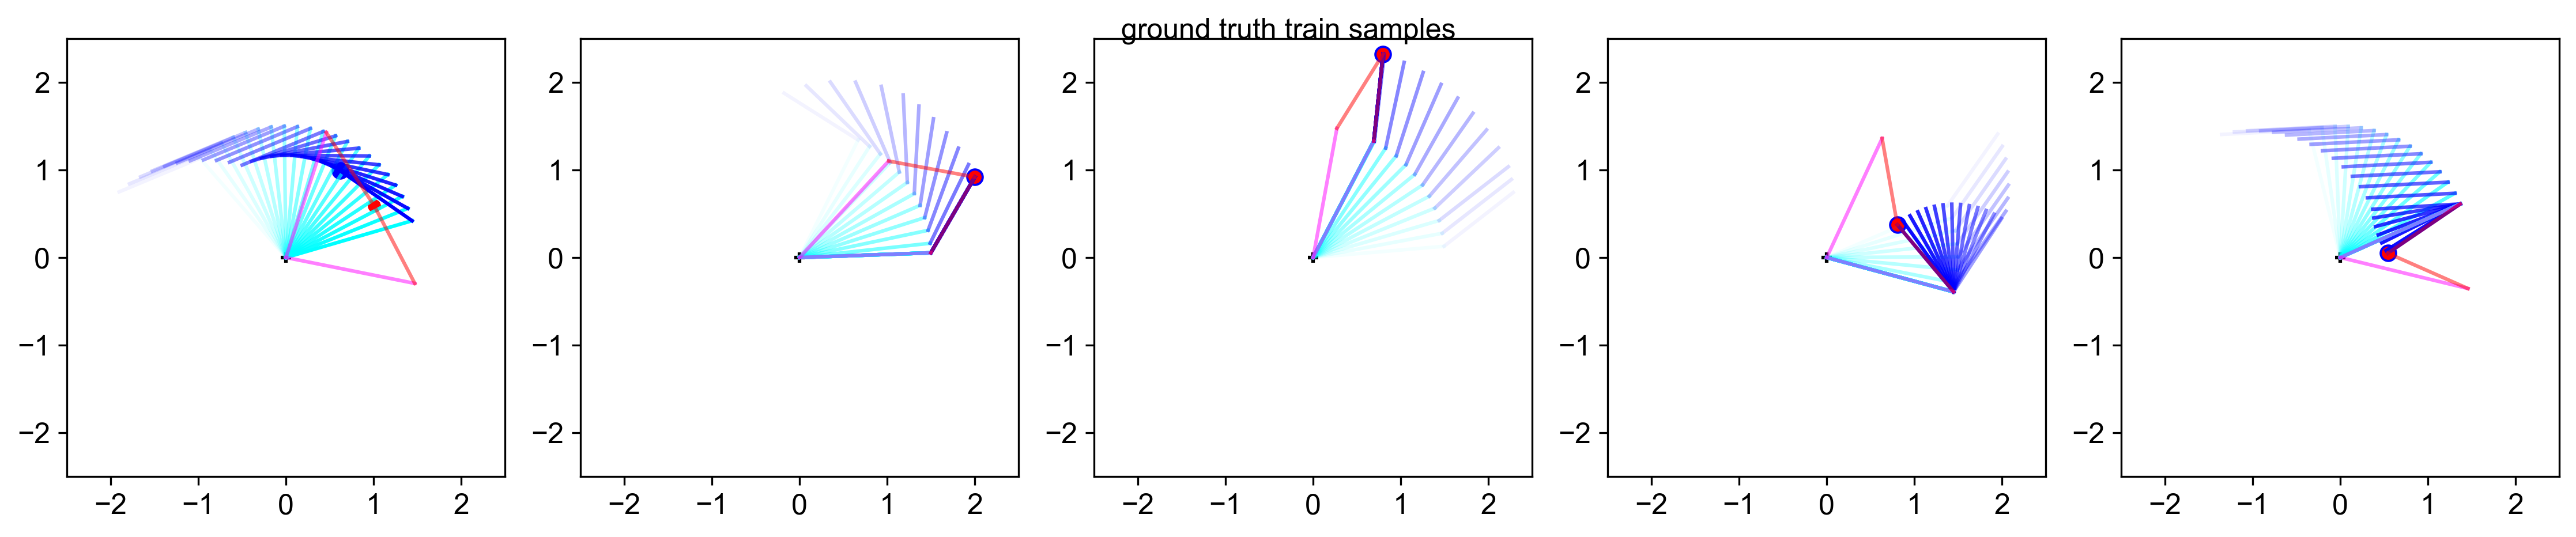

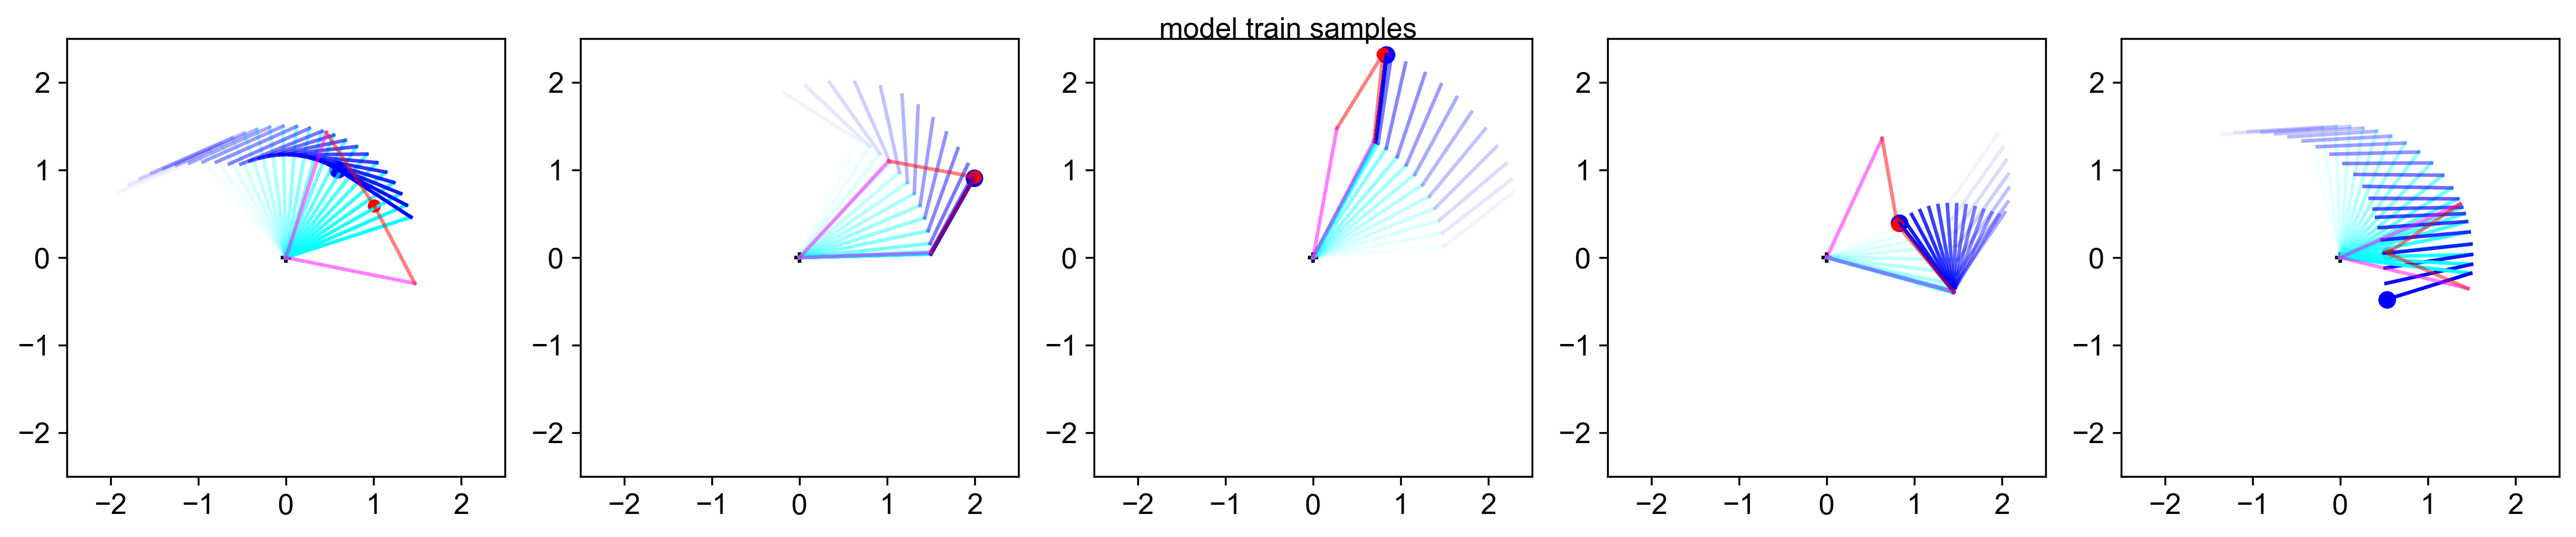

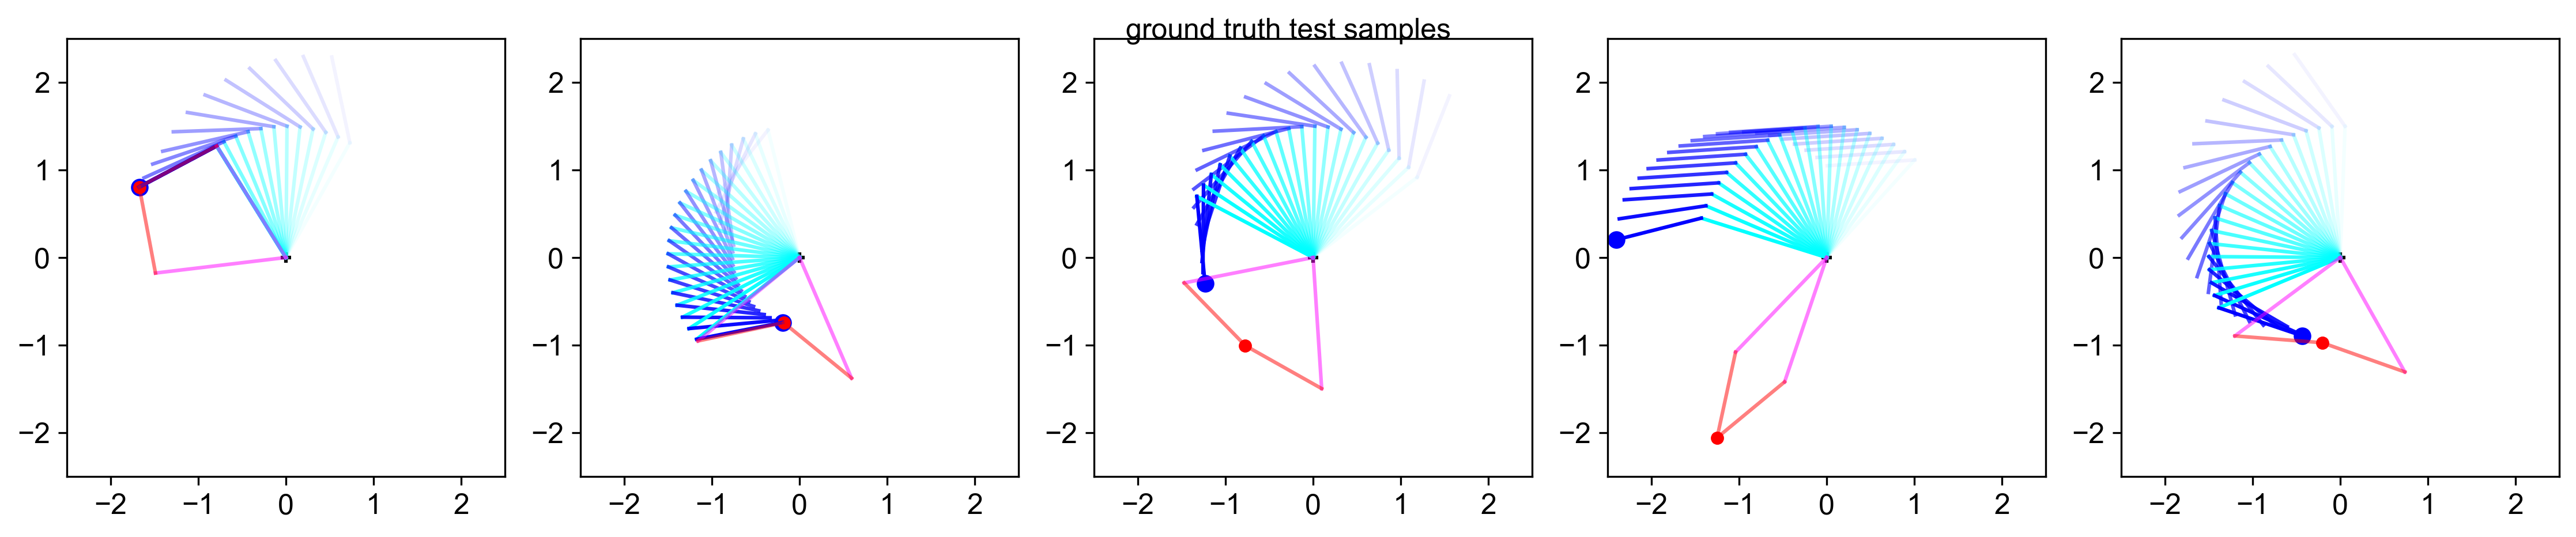

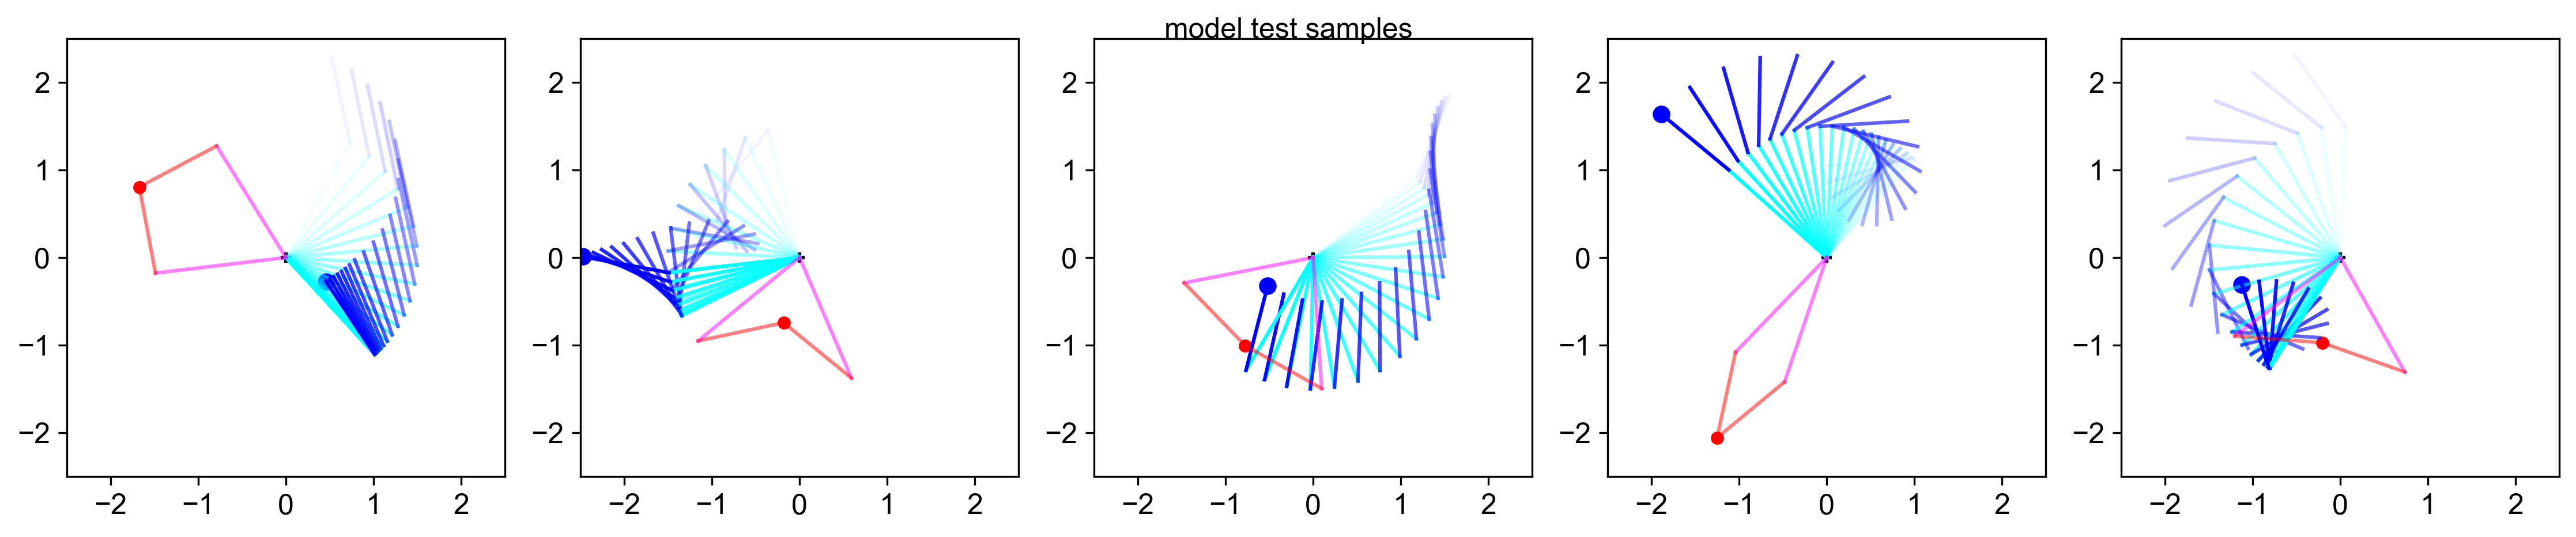

In [14]:
"""Show model rollout performance."""

_N_PLOT = 5
_N_STEPS = 20

task = model.task


class Agent():

    def forward(self, state, goal):
        return task.get_target_action(state, goal)
ground_truth = Agent()


for mode, test in zip(["train", "test"], [False, True]):
    state_torch, goal_torch = task.get_batch(batch_size=_N_PLOT, test=test)
    for agent, agent_name in zip([ground_truth, model], ["ground truth", "model"]):
        states, _, _, target_actions = task.rollout(agent, state_torch, goal_torch, n_steps=_N_STEPS)
        states_joint, states_end = task.pose_to_coords(states)
        goal_joint, goal_end = task.pose_to_coords(goal_torch)
        states = states.detach().cpu().numpy()
        states_joint = states_joint.detach().cpu().numpy()
        states_end = states_end.detach().cpu().numpy()
        goal = goal_torch.detach().cpu().numpy()
        target_actions = target_actions.detach().cpu().numpy()
        fig, axes = plt.subplots(1, _N_PLOT, figsize=(3 * _N_PLOT, 3))
        for i in range(_N_PLOT):
            # Plot segments
            alphas = np.linspace(0, 1, _N_STEPS + 2)[1:]
            for j in range(_N_STEPS + 1):
                axes[i].plot(*zip([0, 0], states_joint[j, i]), c='cyan', alpha=alphas[j])
                axes[i].plot(*zip(states_joint[j, i], states_end[j, i]), c='blue', alpha=alphas[j])
            for i_goal in range(2):
                axes[i].plot(*zip([0, 0], goal_joint[i, i_goal]), c='magenta', alpha=0.5)
                axes[i].plot(*zip(goal_joint[i, i_goal], goal_end[i, i_goal]), c='red', alpha=0.5)
            
            # Scatter hand points
            axes[i].scatter(states_end[-1, i, 0], states_end[-1, i, 1], c='blue', s=40)
            axes[i].scatter(goal_end[i, 0, 0], goal_end[i, 0, 1], c='red', s=20)

            axes[i].set_xlim(-2.5, 2.5)
            axes[i].set_ylim(-2.5, 2.5)
            axes[i].set_aspect('equal')
            axes[i].set_xticks([-2, -1, 0, 1, 2])
            axes[i].set_yticks([-2, -1, 0, 1, 2])
            axes[i].scatter(0, 0, c='k', marker='+', s=20)
        fig.tight_layout()
        fig.suptitle(f"{agent_name} {mode} samples")